## __Data Exploration__
We will be using our agriculture dataset to explore the effect climate change has on crops in Maji Ndogo. As a refresher of our data, examine the data dictionary.

### **Data Dictionary**

**1. Geographic features**

- **Field_ID:** A unique identifier for each field (BigInt).

- **Elevation:** The elevation of the field above sea level in metres (Float).

- **Latitude:** Geographical latitude of the field in degrees (Float). (DUMMY VARIABLE – the simulation might have created a relationship)

- **Longitude:** Geographical longitude of the field in degrees (Float). (DUMMY VARIABLE – the simulation might have created a relationship)

- **Location:** Province the field is in (Text).

- **Slope:** The slope of the land in the field (Float).

**2. Weather features**

- **Rainfall:** Amount of rainfall in the area in mm (Float).

- **Min_temperature_C:** Average minimum temperature recorded in Celsius (Float). (DUMMY VARIABLE)

- **Max_temperature_C:** Average maximum temperature recorded in Celsius (Float). (DUMMY VARIABLE)

- **Ave_temps:** Average temperature in Celsius (Float).

**3. Soil and crop features**

- **Soil_fertility:** A measure of soil fertility where 0 is infertile soil and 1 is very fertile soil (Float).

- **Soil_type:** Type of soil present in the field (Text).

- **pH:** pH level of the soil, which is a measure of how acidic/basic the soil is (Float).

**4. Farm management features**

- **Field_ID:** Corresponding field identifier (BigInt).

- **Pollution_level:** Level of pollution in the area where 0 is unpolluted and 1 is very polluted (Float).

- **Plot_size:** Size of the plot in the field (Ha) (Float). (DUMMY VARIABLE)

- **Crop_type:** Type of crop chosen for cultivation (Text).

- **Annual_yield:** Annual yield from the field (Float). This is the total output of the field. The field size and type of crop will affect the annual yield. (DUMMY VARIABLE – removed)

<br>

**5. Target variable**
- **Standard_yield:** Standardised yield expected from the field, normalised per crop (Float). This is independent of field size or crop type. Multiplying this number by the field size and average crop yield will give the Annual_yield.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from plot import style_plot

In [3]:
from pathlib import Path
from field_data_processor import FieldDataProcessor

import logging

# ---------------------------------------------------------
# Logging
# ---------------------------------------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)


# ---------------------------------------------------------
# Database path
# ---------------------------------------------------------

db_path = (
    Path.home()
    / "Desktop"
    / "ALX"
    / "Data Science"
    / "DS-5 Supervised Learning II – Classification & Model Selection"
    / "notebook"
    / "Maji_Ndogo_farm_survey_small.db"
)
# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

config_params = {

    "sql_query": """
        SELECT *
        FROM geographic_features
        LEFT JOIN weather_features USING (Field_ID)
        LEFT JOIN soil_and_crop_features USING (Field_ID)
        LEFT JOIN farm_management_features USING (Field_ID)
    """,

    # Convert Windows path into a SQLite URL
    "db_path": f"sqlite:///{db_path.as_posix()}",

    "columns_to_rename": {
        "Annual_yield": "Crop_type",
        "Crop_type": "Annual_yield"
    },

    "values_to_rename": {
        "cassaval": "cassava",
        "wheatn": "wheat",
        "teaa": "tea"
    },

    "weather_mapping_csv": (
        "https://raw.githubusercontent.com/Explore-AI/Public-Data/"
        "master/Maji_Ndogo/Weather_data_field_mapping.csv"
    ),

    "regex_patterns": {
        "Rainfall": r"(\d+(\.\d+)?)\s?mm",

        "Temperature": r"(\d+(\.\d+)?)\s?C",

        "Pollution_level": (
            r"=\s*(-?\d+(\.\d+)?)|Pollution at\s*(-?\d+(\.\d+)?)"
        )
    }
}


In [4]:
field_processor = FieldDataProcessor(config_params)
field_processor.process()

field_df = field_processor.df

2026-09-01 10:21:52,446 - data_ingestion - INFO - Database engine created successfully.


2026-09-01 10:21:52,500 - data_ingestion - INFO - Query executed successfully.
2026-09-01 10:21:52,501 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-09-01 10:21:52,503 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-09-01 10:21:55,987 - data_ingestion - INFO - CSV file read successfully from the web.


In [5]:
df = field_df.drop(
    "Weather_station",
    axis=1
)

df.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


#### __Prepare the predictors and target__

In [6]:
# Target
y = df["Standard_yield"]

# Select numeric predictor variables
X = df.select_dtypes(include="number").drop(
    columns=["Standard_yield"]
)

print("Predictors:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Predictors:
['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Slope', 'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility', 'pH', 'Pollution_level', 'Plot_size', 'Annual_yield']

Shape of X: (5654, 14)
Shape of y: (5654,)


This automatically excludes:

- Location
- Soil_type
- Crop_type

because they are non-numeric.

It also excludes Standard_yield because that is our target.

#### __Fit the Decision Tree Regressor__

Because the question specifically says to fit the model to the entire dataset, we don't need a train/test split for this particular exercise.

In [7]:
# Create the decision tree regressor
tree_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

# Fit the model
tree_model.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

#### __Make Prediction__

In [8]:
y_pred = tree_model.predict(X)

#### __Calculate MSE and R²__

In [9]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.0075
R²: 0.3968


__Interpretation__

- **MSE** = 0.0075: The model's squared prediction errors are relatively small, indicating that the predicted Standard_yield values are reasonably close to the observed values. However, MSE is most meaningful when compared with another model or a baseline.
- **R²** = 0.3968: The decision tree explains approximately 39.7% (about 40%) of the variation in Standard_yield using the available numeric predictors.
- Therefore, the model has some predictive value, but approximately 60.3% of the variation remains unexplained by this depth-4 tree.

#### __Business Interpretation__

The depth-4 decision tree provides moderate explanatory power, explaining approximately 40% of the variation in standardized crop yield. This suggests that environmental and farm-related variables contain meaningful information for understanding crop productivity, but they do not fully explain yield differences. Additional factors or a more flexible modelling approach may be required to improve predictive performance.

### __Exercise 2__

While the model shows some predictive capability with a moderate R² value, there is still room for improvement, particularly in reducing the MSE and potentially increasing the explanatory power of the model. This can be achieved through further feature selection, hyperparameter tuning, or exploring alternative modelling techniques.

Let's start with feature selection. What environmental factors have the highest correlation with crop yields, and how can we use this information to improve the predictive performance of our model?

Conduct feature selection using a **correlation matrix** to select relevant features for predicting `Standard_yield`.

Visualise the matrix to better identify the features with the highest correlation with `Standard_yield`.

Regarding features to retain and eliminate, what do the results suggest? Have you thought about the independent features that might be correlated?

### 1. **Select Numerical Features**

In [10]:
# Select numerical columns
numeric = df.select_dtypes(include="number")

numeric.head()

,Field_ID,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,Pollution_level,Plot_size,Annual_yield,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,6.169393,0.085267,1.3,0.751354,0.577964
1,30629,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,5.676648,0.399684,2.2,1.069865,0.486302
2,39924,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,5.331993,0.358029,3.4,2.208801,0.649647
3,5754,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,5.328150,0.286687,2.4,1.277635,0.532348
4,14146,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,5.721234,0.043190,1.5,0.832614,0.555076


### 2. **Create Correlation Matrix**

In [11]:
corr_matrix = numeric.corr()

### 3. **Visualize the correlation matrix**

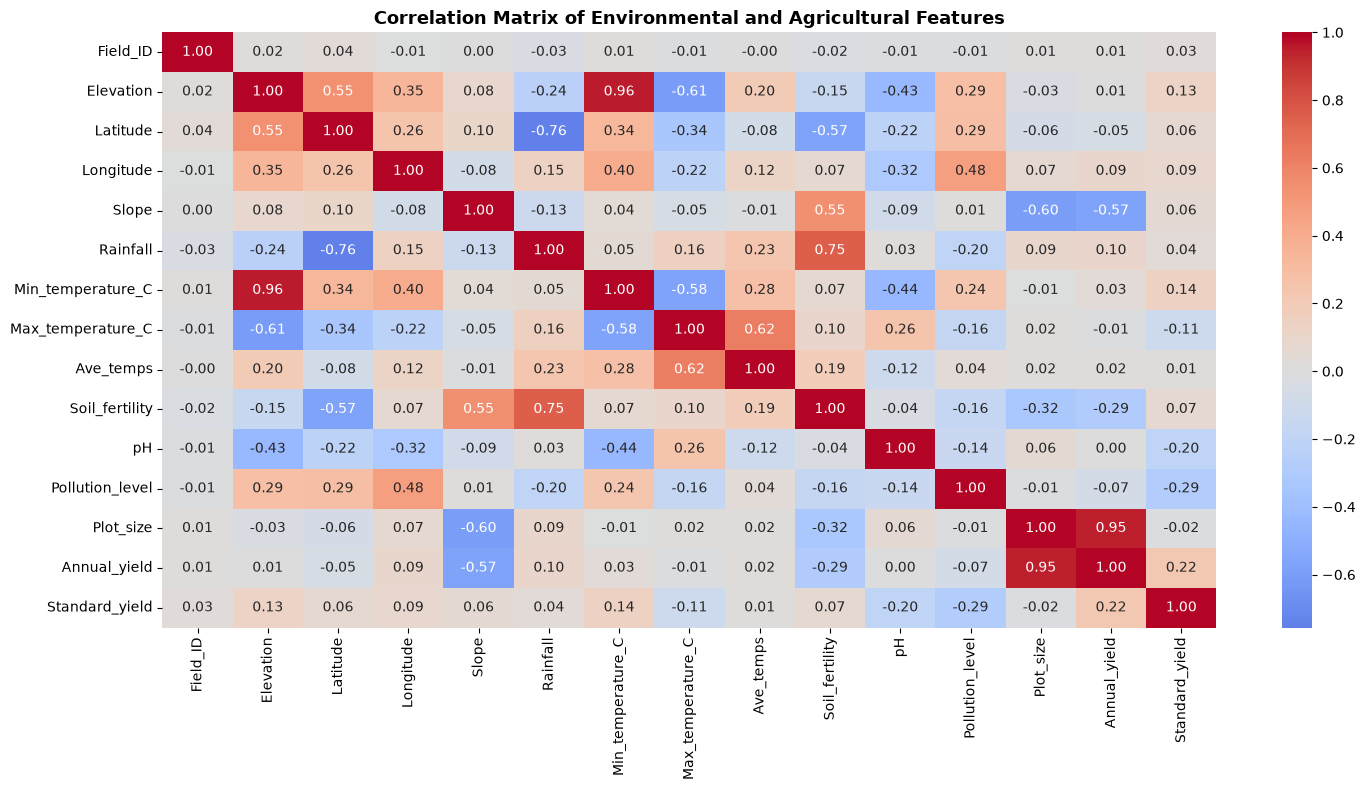

In [12]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

style_plot(
    ax,
    title = "Correlation Matrix of Environmental and Agricultural Features",
    remove_spine = False,
    grid = False
)

plt.tight_layout()
plt.show()

### 4. **Focus specifically on Standard_yield**

Rather than manually inspecting the entire matrix, rank the correlations with the target:

In [13]:
target_corr = (
    corr_matrix["Standard_yield"]
    .drop("Standard_yield")
    .sort_values(key=abs, ascending=False)
)

target_corr

Pollution_level     -0.285761
Annual_yield         0.220812
pH                  -0.196613
Min_temperature_C    0.144233
Elevation            0.129248
Max_temperature_C   -0.111649
Longitude            0.085343
Soil_fertility       0.070205
Latitude             0.061724
Slope                0.056991
Rainfall             0.039217
Field_ID             0.030802
Plot_size           -0.017014
Ave_temps            0.006786
Name: Standard_yield, dtype: float64

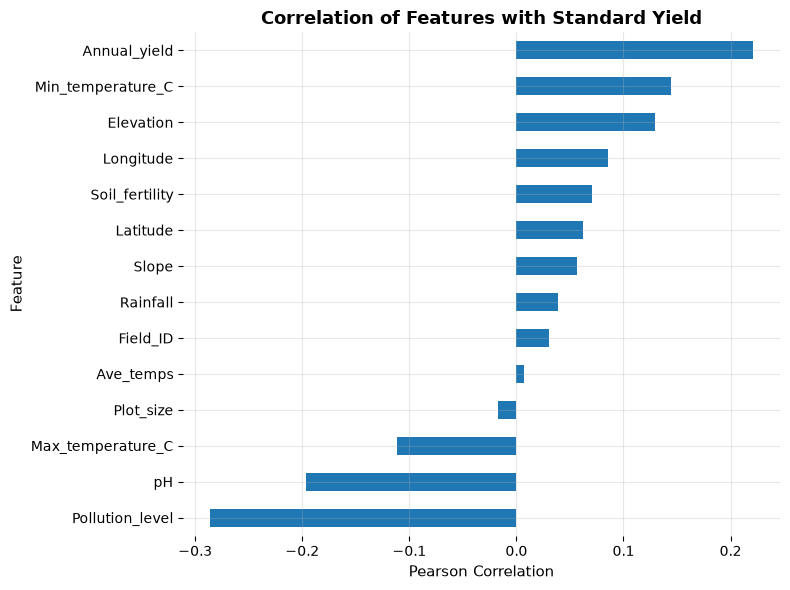

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

target_corr.sort_values().plot(
    kind="barh"
)

style_plot(
    ax,
    title = "Correlation of Features with Standard Yield",
    xlabel = "Pearson Correlation",
    ylabel = "Feature"
)

plt.tight_layout()
plt.show()

In [16]:
selected_features = [
    "Pollution_level",
    "pH",
    "Min_temperature_C",
    "Elevation",
    "Max_temperature_C"
]


X = df[selected_features]
y = df["Standard_yield"]

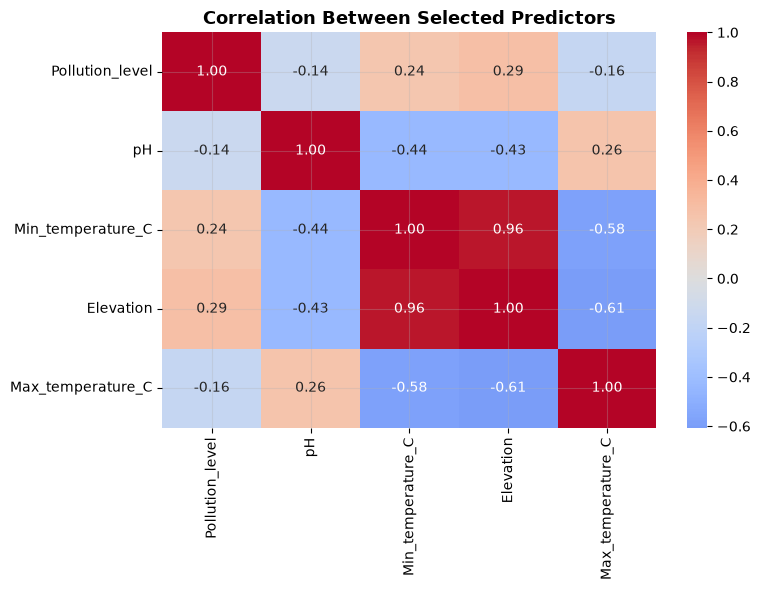

In [17]:
feature_corr = df[selected_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

style_plot(
    ax,
    title = "Correlation Between Selected Predictors"
)

plt.tight_layout()
plt.show()

### **Key findings**
- `Min_temperature_C and Elevation:` 0.96
This is an extremely strong positive correlation. These two predictors contain very similar information in this dataset. Keeping both in a linear regression model could cause serious multicollinearity.
- `Elevation and Max_temperature_C:` -0.61
This is a moderately strong negative relationship and is also worth monitoring.
- `Min_temperature_C and Max_temperature_C`: -0.58
These variables are also substantially correlated.
- `pH with temperature/elevation`: around -0.43 to -0.44
This is moderate correlation, but not as concerning as the 0.96 relationship.
- `Pollution_level` with the other predictors: between -0.16 and 0.29
These relationships are relatively weak, so pollution appears to provide more independent information.

Min_temperature_C has a slightly stronger correlation with Standard_yield, so an initial reduced feature set could be:

In [18]:
selected_features = [
    "Pollution_level",
    "pH",
    "Min_temperature_C",
    "Max_temperature_C"
]

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[
    [
        "Pollution_level",
        "pH",
        "Min_temperature_C",
        "Max_temperature_C"
    ]
]

X_vif = sm.add_constant(X)

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif

,Feature,VIF
0,const,1.000000
1,Pollution_level,1.061751
2,pH,1.236266
3,Min_temperature_C,1.767928
4,Max_temperature_C,1.500097


The VIF analysis confirms that the selected predictors have low levels of multicollinearity. All VIF values are below 2, with the highest value being 1.77 for Min_temperature_C. This indicates that the predictors provide relatively independent information to the linear regression model. The earlier correlation analysis identified a very strong correlation between Min_temperature_C and Elevation (0.96). By excluding Elevation, the multicollinearity problem was substantially reduced. Therefore, Pollution_level, pH, Min_temperature_C, and Max_temperature_C provide a statistically reasonable feature set for the next stage of model evaluation.

### **Exercise 3**
Now that we know which features could work best for our model, let's run our model again on a reduced dataset.

Reduce the dataset to only include `Pollution_level`, `Min_temperature_C`, `Longitude`, and `pH`.

Refit the decision tree regressor model using the reduced dataset and evaluate the model's performance on the test set to determine if there's an improvement in MSE and R² values.

Does reducing the dataset lead to an improvement in the predictive performance of our model?

Run the model on different combinations of the reduced dataset. Is there a combination of variables or a single variable that improves the MSE and R²?

In [21]:
reduced_features = [
    "Pollution_level",
    "Min_temperature_C",
    "Longitude",
    "pH"
]


X_reduced = df[reduced_features]
y = df["Standard_yield"]

X_reduced.head()

,Pollution_level,Min_temperature_C,Longitude,pH
0,0.085267,-3.1,-7.556202,6.169393
1,0.399684,-3.9,-1.051539,5.676648
2,0.358029,-1.8,0.115156,5.331993
3,0.286687,-5.8,-6.592215,5.328150
4,0.043190,-2.5,-7.952609,5.721234


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
tree = DecisionTreeRegressor(
    random_state=42
)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R²: {r2:.4f}")

Test MSE: 0.0132
Test R²: 0.0085


### __Exercise 4__
Now that we have attempted feature engineering, let's move on to parameter tuning. What is the optimal depth for the decision tree model that maximises predictive performance while avoiding overfitting?
Use a loop to fit decision tree models with depths ranging from 1 to 10 and assess the MSE and R² scores for each depth. Analyse the results to identify the depth that maximises R² while avoiding significant increases in MSE, indicating optimal model complexity.

In [27]:
results = []

for depth in range(1, 11):

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "max_depth": depth,
        "MSE": mse,
        "R2": r2
    })

depth_results = pd.DataFrame(results)

depth_results

,max_depth,MSE,R2
0,1,0.011738,0.119145
1,2,0.009904,0.256730
2,3,0.009118,0.315718
3,4,0.008976,0.326412
4,5,0.008948,0.328500
5,6,0.008939,0.329161
6,7,0.008936,0.329400
7,8,0.008991,0.325280
8,9,0.009719,0.270628
9,10,0.010105,0.241694


Optimal Tree Depth: The optimal max_depth is 7, as it achieves the highest R² (0.3294) and the lowest MSE (0.008936) among the tested models. Although depths 5–7 produce very similar results, depth 7 provides the best predictive performance. Beyond depth 7, both metrics deteriorate, indicating that increasing model complexity does not improve generalisation and may lead to overfitting. Therefore, max_depth=7 provides the best balance between model complexity and predictive performance.

Business interpretation: The model explains approximately 32.9% of the variation in the target variable on the evaluation data. This is a meaningful but moderate predictive capability, indicating that other factors not captured by the current features also contribute substantially to the outcome.